# Download and import the required libraries

In [2]:
import os
import torch
os.environ['TORCH'] = torch.__version__

!pip install torch_geometric
!pip install -q torch-scatter -f https://data.pyg.org/whl/torch-${TORCH}.html
!pip install -q torch-sparse -f https://data.pyg.org/whl/torch-${TORCH}.html
!pip install -q git+https://github.com/pyg-team/pytorch_geometric.git

# !pip install umap-learn torch-scatter torch-sparse torch-cluster torch-spline-conv pyg_lib -f https://data.pyg.org/whl/torch-{version}.html

import numpy as np
import time
import torch.nn.functional as F
from torch.nn import Linear, Sequential, BatchNorm1d, ReLU
from torch_geometric.loader import DataLoader
from torch_geometric.datasets import TUDataset
from torch_geometric.transforms import OneHotDegree
from torch_geometric.utils import degree
from torch_geometric.nn import GINConv, global_add_pool, global_mean_pool
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.metrics import adjusted_rand_score
from sklearn.manifold import TSNE
try:
    import umap.umap_ as umap
except ImportError:
    import umap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 24.1 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 89.9 MB/s eta 0:00:0000:010:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 46.3 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


# Load the Dataset

In [3]:
import torch_geometric.transforms as T

def get_dataset(name):
    if (name == 'MUTAG'):
        dataset = TUDataset(root='./data', name=name, use_node_attr=True)
        
    elif (name=='ENZYMES'):
        dataset = TUDataset(
            root='./data', 
            name='ENZYMES',
            use_node_attr=True,  # Ensure continuous features are loaded
            transform=T.Compose([
                T.NormalizeFeatures(), # Normalize the continuous features
                T.OneHotDegree(max_degree=15) # Adds structural degree info
            ])
        )

    else: 
        dataset = TUDataset(root='./data', name=name, use_node_attr=True)

        # Handle datasets with no node feature by adding one-hot encoded node degrees as features
        max_degree = 0
        for data in dataset:
            d = degree(data.edge_index[0], dtype=torch.long)
            max_degree = max(max_degree, int(d.max()))
        
        # Apply the transform to generate features
        dataset.transform = OneHotDegree(max_degree)
    
    return dataset

# GIN Architecture

In [4]:
class GIN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.5, num_layers=3):
        super().__init__()
        self.dropout = dropout
        self.num_layers = num_layers

        # Layer 0: Mapping input features to hidden dimension
        # so it has the same weight as the rest of the layers in the final embedding
        self.conv_zero = Sequential(
            Linear(in_channels, hidden_channels),
            BatchNorm1d(hidden_channels),
            ReLU()
        )

        # Layers 1 - K: GIN convolutions
        self.convs = torch.nn.ModuleList()
        for _ in range(num_layers):
            mlp = Sequential(
                Linear(hidden_channels, hidden_channels),
                BatchNorm1d(hidden_channels),
                ReLU(),
                Linear(hidden_channels, hidden_channels),
                BatchNorm1d(hidden_channels),
                ReLU()
            )
            conv = GINConv(mlp, train_eps=True)
            self.convs.append(conv)
        
        # Classifier
        # Input dim is hidden_channels*(num_layers+1) because we concat Layer 0 + K layers
        self.lin1 = Linear(hidden_channels*(num_layers+1), hidden_channels)
        self.lin2 = Linear(hidden_channels, out_channels)
    
    def forward(self, x, edge_index, batch):
        x = self.conv_zero(x)
        node_embeddings = [x]

        # Node Embeddings (for every GIN Layer)
        # [nodes_in_batch, hidden_dimension] * (num_layers + 1)
        for conv in self.convs:
            x = conv(x, edge_index)
            x = F.dropout(x, p=self.dropout, training=self.training)
            node_embeddings.append(x)

        # Graph-level readout of node embeddings to produce Graph Embeddings (at each layer)
        # We avg the node embeddings at each graph to produce a Graph Embedding 
        # [batch_size, hidden_dimension] * (num_layers + 1)
        pooled = [global_mean_pool(h, batch) for h in node_embeddings]
            
        # Concatenate graph embeddings from all layers
        # [batch_size, hidden_dimension * (num_layers + 1)] = [batch_size, embedding_size]
        graph_embedding = torch.cat(pooled, dim=1)

        # Classifier
        h = self.lin1(graph_embedding)
        h = h.relu()
        h = F.dropout(h, p=self.dropout, training=self.training)
        out = self.lin2(h)

        return F.log_softmax(out, dim=1), F.softmax(out, dim=1), graph_embedding


def train(model, train_loader, optimizer):
    model.train()
    total_loss = 0
    total_graphs = 0
    
    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        
        out, _, _ = model(data.x, data.edge_index, data.batch)
        
        loss = F.nll_loss(out, data.y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 2.0)
        optimizer.step()
        
        total_loss += loss.item() * data.num_graphs 
        total_graphs += data.num_graphs
        
    return total_loss / total_graphs

def test(model, loader):
    model.eval()
    prediction_list, label_list, probabilities_list, embedding_list = [], [], [], []

    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            _, probabilities, embeddings = model(data.x, data.edge_index, data.batch)
            predictions = probabilities.argmax(dim=1)
            
            prediction_list.append(predictions.detach().cpu())
            label_list.append(data.y.detach().cpu())
            probabilities_list.append(probabilities.detach().cpu())
            embedding_list.append(embeddings.detach().cpu())
        
    y_pred = torch.cat(prediction_list).numpy()
    y_true = torch.cat(label_list).numpy()
    y_probs = torch.cat(probabilities_list).numpy()
    final_embeddings = torch.cat(embedding_list)
    
    return y_true, y_pred, y_probs, final_embeddings

# Classification

In [18]:
# CONFIGURATION
DATASET_NAME = 'ENZYMES'  # Options: 'MUTAG', 'ENZYMES', 'IMDB-MULTI'
BATCH_SIZE = 64
EMBEDDING_SIZE = 256
# Our GIN implementation has 4 components (Layer0 + 3 GIN Layers) and the final embedding
# is the concatenation of each component's embedding, so the final embedding size is hidden_dim * 4
HIDDEN_CHANNELS = int(EMBEDDING_SIZE/4) 
DROPOUT = 0.5
EPOCHS = 300
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
!mkdir best_models 

# LOAD DATA
dataset = get_dataset(DATASET_NAME)
X = np.zeros(len(dataset)) # Dummy features for splitter
y = np.array([data.y.item() for data in dataset]) # Labels for stratification
print(f"Dataset: {DATASET_NAME}")
print(f"Number of graphs: {len(dataset)}")
print(f"Number of classes: {dataset.num_classes}")
print(f"Number of node features: {dataset.num_features}")
print(f"Device: {device}")
print("-" * 60)

# SETUP 10-FOLD SPLITTER
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Lists to store results across 10 folds
results = {
    'acc': [], 'f1': [], 'auc': [], 
    'train_time': [], 'infer_time': [], 'memory': []
}
top_acc_so_far = 0

# CROSS VALIDATION LOOP
for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
    # SPLIT DATA
    train_dataset = dataset[torch.tensor(train_idx)]
    test_dataset = dataset[torch.tensor(test_idx)]
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    # SETUP MODEL
    model = GIN(
        in_channels=dataset.num_features, 
        hidden_channels=HIDDEN_CHANNELS, 
        out_channels=dataset.num_classes, 
        dropout=DROPOUT,
        num_layers=3,
    ).to(device)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, min_lr=0.00001)

    # TRAINING LOOP
    best_fold_metrics = {'acc': 0.0, 'f1': 0.0, 'auc': 0.0, 'infer_time': 0.0}
    total_train_time = 0.0
    
    # Reset GPU memory tracking for this fold
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()

    for epoch in range(EPOCHS): 
        # Measure Training Time
        start_train = time.time()
        train_loss = train(model, train_loader, optimizer)
        total_train_time += (time.time() - start_train)
        
        # Measure Generation (Inference) Time
        start_infer = time.time()
        y_true, y_pred, y_probs, _ = test(model, test_loader)
        infer_time = time.time() - start_infer
        
        test_acc = (y_pred == y_true).sum() / len(y_true)
        scheduler.step(train_loss)     

        # If this is the best model so far (in this fold), calculate and store all detailed metrics
        if test_acc > best_fold_metrics['acc']:
            best_fold_metrics['acc'] = test_acc
            best_fold_metrics['infer_time'] = infer_time
            
            # Calculate F1 and AUC
            try:
                if dataset.num_classes == 2:
                    # For binary, pass only the positive class probability
                    best_fold_metrics['auc'] = roc_auc_score(y_true, y_probs[:, 1])
                    best_fold_metrics['f1'] = f1_score(y_true, y_pred, average='binary')
                else:
                    best_fold_metrics['auc'] = roc_auc_score(y_true, y_probs, multi_class='ovr', average='weighted')
                    best_fold_metrics['f1'] = f1_score(y_true, y_pred, average='weighted')
            except ValueError:
                best_fold_metrics['auc'] = 0.5

            # Save the best model across folds
            if test_acc > top_acc_so_far:
                top_acc_so_far = test_acc
                torch.save(model.state_dict(), './best_model.pth')
                
    # Record Memory (Peak VRAM used during this fold in MB)
    max_memory = torch.cuda.max_memory_allocated() / 1024**2 if torch.cuda.is_available() else 0

    # Append Fold Results
    results['acc'].append(best_fold_metrics['acc'])
    results['f1'].append(best_fold_metrics['f1'])
    results['auc'].append(best_fold_metrics['auc'])
    results['train_time'].append(total_train_time)
    results['infer_time'].append(best_fold_metrics['infer_time'])
    results['memory'].append(max_memory)
    
    print(f"[Fold {fold+1:02d}] Acc: {best_fold_metrics['acc']:.4f} | F1: {best_fold_metrics['f1']:.4f} | AUC: {best_fold_metrics['auc']:.2f} | Time: {total_train_time:.2f}s")

# PRINT FINAL RESULTS
print("-" * 60)
print(f"Final 10-Fold Results ({DATASET_NAME} - ΕΜΒ {EMBEDDING_SIZE} - {EPOCHS} EPOCHS):")
print(f"Accuracy:        {np.mean(results['acc'])*100:.2f}% ± {np.std(results['acc'])*100:.2f}")
print(f"F1-Score:        {np.mean(results['f1']):.4f} ± {np.std(results['f1']):.4f}")
print(f"AUC:             {np.mean(results['auc']):.4f} ± {np.std(results['auc']):.4f}")
print(f"Total Train Time:{np.mean(results['train_time']):.2f}s ± {np.std(results['train_time']):.2f}")
print(f"Generation Time: {np.mean(results['infer_time']):.4f}s ± {np.std(results['infer_time']):.4f}")
print(f"Peak Memory Use: {np.mean(results['memory']):.2f} MB")
print("-" * 60)

Processing...
Done!


Dataset: ENZYMES
Number of graphs: 600
Number of classes: 6
Number of node features: 37
Device: cuda
------------------------------------------------------------
[Fold 01] Acc: 0.4667 | F1: 0.4671 | AUC: 0.73 | Time: 47.71s
[Fold 02] Acc: 0.4833 | F1: 0.4903 | AUC: 0.71 | Time: 48.37s
[Fold 03] Acc: 0.4167 | F1: 0.3828 | AUC: 0.70 | Time: 47.85s
[Fold 04] Acc: 0.5167 | F1: 0.5048 | AUC: 0.76 | Time: 46.87s
[Fold 05] Acc: 0.5333 | F1: 0.5056 | AUC: 0.82 | Time: 46.81s
[Fold 06] Acc: 0.6167 | F1: 0.6085 | AUC: 0.82 | Time: 46.74s
[Fold 07] Acc: 0.4833 | F1: 0.4689 | AUC: 0.75 | Time: 46.82s
[Fold 08] Acc: 0.5333 | F1: 0.5272 | AUC: 0.77 | Time: 46.80s
[Fold 09] Acc: 0.4833 | F1: 0.4863 | AUC: 0.71 | Time: 46.43s
[Fold 10] Acc: 0.5500 | F1: 0.5377 | AUC: 0.76 | Time: 46.84s
------------------------------------------------------------
Final 10-Fold Results (ENZYMES - ΕΜΒ 256 - 300 EPOCHS):
Accuracy:        50.83% ± 5.18
F1-Score:        0.4979 ± 0.0548
AUC:             0.7531 ± 0.0394
Tota

# Clustering 

Graph Embeddings Shape: (600, 256)
-----------------------------
Clustering Performance (ARI):
K-Means ARI:          0.3510
Spectral Clustering:  0.3834
-----------------------------


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


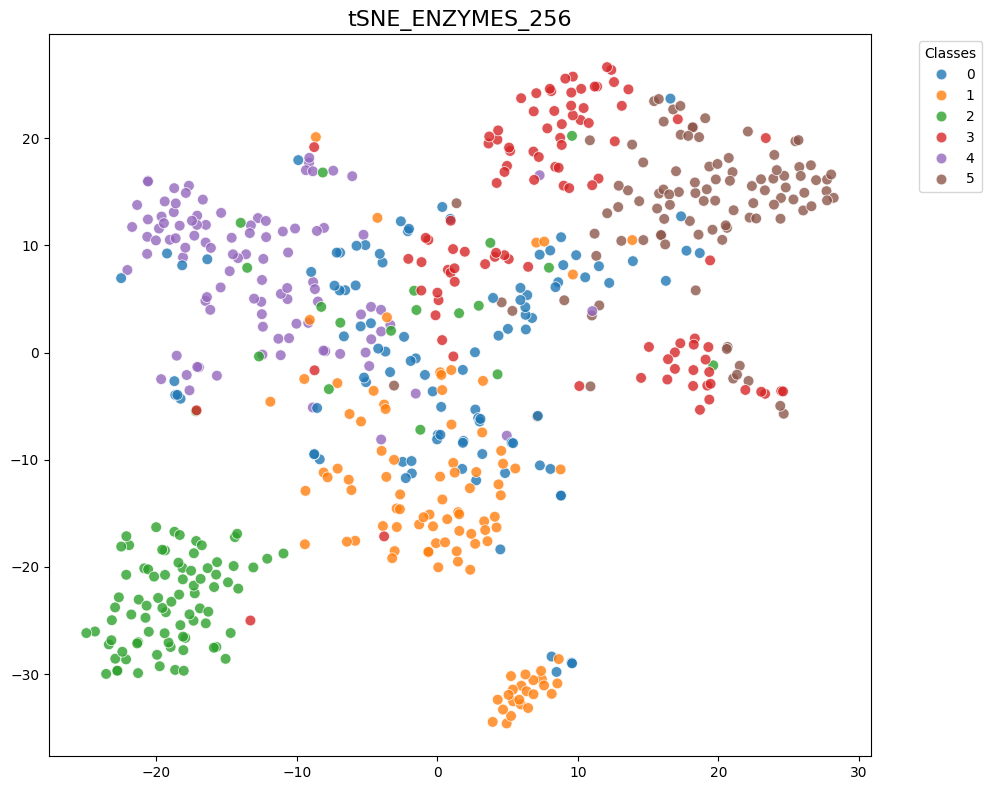

Saved: tsne_plot.png


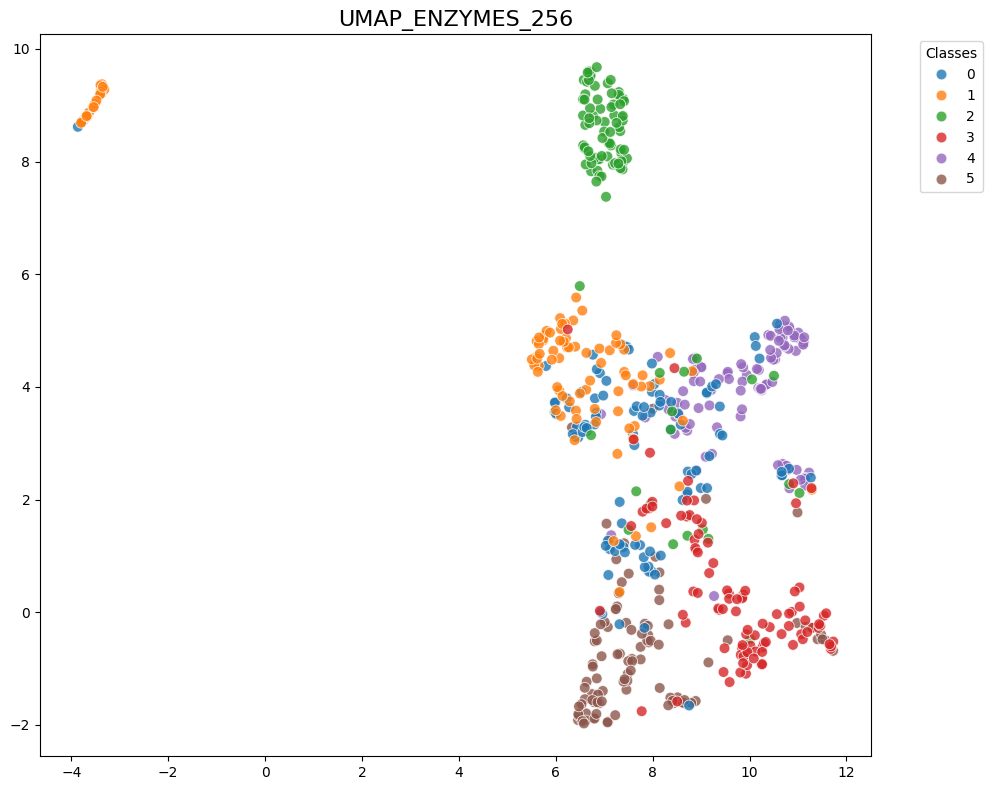

Saved: umap_plot.png
-----------------------------------------
QUALITATIVE ASSESSMENT: Medium Separation
-----------------------------------------


In [25]:
# EXTRACT GRAPH EMBEDDINGS FROM THE ENTIRE DATASETS
full_loader = DataLoader(dataset, batch_size=64, shuffle=False) # no shuffle for consistent plotting

# Get Embeddings using the best model from training
model.load_state_dict(torch.load('./best_model.pth'))
all_embeddings = []
all_labels = []

with torch.no_grad():
    for data in full_loader:
        data = data.to(device)
        _, _, embeddings = model(data.x, data.edge_index, data.batch)
        all_embeddings.append(embeddings.cpu().numpy())
        all_labels.append(data.y.cpu().numpy())

X_emb = np.concatenate(all_embeddings, axis=0)
y_true = np.concatenate(all_labels, axis=0)

print(f"Graph Embeddings Shape: {X_emb.shape}")

# CLUSTERING & METRICS (ARI)
num_classes = dataset.num_classes

# K-Means
kmeans = KMeans(n_clusters=num_classes, random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X_emb)
ari_kmeans = adjusted_rand_score(y_true, y_kmeans)

# Spectral Clustering
spectral = SpectralClustering(n_clusters=num_classes, assign_labels='discretize', random_state=42, affinity='nearest_neighbors')
y_spectral = spectral.fit_predict(X_emb)
ari_spectral = adjusted_rand_score(y_true, y_spectral)

print("-" * 29)
print(f"Clustering Performance (ARI):")
print(f"K-Means ARI:          {ari_kmeans:.4f}")
print(f"Spectral Clustering:  {ari_spectral:.4f}")
print("-" * 29)

# VISUALIZATION (t-SNE & UMAP)
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
z_tsne = tsne.fit_transform(X_emb)

umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
z_umap = umap_model.fit_transform(X_emb)

def plot_embedding(z, labels, title, filename):
    plt.figure(figsize=(10, 8))
    sns.scatterplot(x=z[:,0], y=z[:,1], hue=labels, palette='tab10', s=60, alpha=0.8)
    plt.title(title, fontsize=16)
    plt.legend(title='Classes', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(filename)
    plt.show()
    print(f"Saved: {filename}")

plot_embedding(z_tsne, y_true, f"tSNE_{DATASET_NAME}_{EMBEDDING_SIZE}", "tsne_plot.png")
plot_embedding(z_umap, y_true, f"UMAP_{DATASET_NAME}_{EMBEDDING_SIZE}", "umap_plot.png")

# QUALITATIVE ASSESSMENT
def assess_separation(ari_score):
    if ari_score > 0.5:
        return "Clear Separation"
    elif ari_score > 0.2:
        return "Medium Separation"
    else:
        return "No/Poor Separation"

quality = assess_separation(max(ari_kmeans, ari_spectral))
print("-" * 41)
print(f"QUALITATIVE ASSESSMENT: {quality}")
print("-" * 41)

In [ ]:
import warnings
warnings.filterwarnings('ignore', message='.*n_jobs value 1 overridden.*')
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import umap
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.metrics import adjusted_rand_score
import numpy as np

# === CONFIGURATION ===
# Check for 'full_embeddings' first (from the new code), otherwise fall back to 'final_embeddings'
if 'full_embeddings' in locals() and torch.is_tensor(full_embeddings):
    # Use the FULL dataset
    print("Using FULL dataset embeddings.")
    X = full_embeddings.cpu().numpy()
    y_true = y_true_full # Don't forget to update labels to match!
    
elif 'final_embeddings' in locals() and torch.is_tensor(final_embeddings):
    # Fallback to just Test set
    print("Using TEST set embeddings.")
    X = final_embeddings.cpu().numpy()
else:
    print("Warning: No embeddings found. Using random data.")
    X = np.random.rand(100, 32)
    y_true = np.random.randint(0, 2, 100)
    
if 'dataset' in locals():
    num_classes = dataset.num_classes
else:
    num_classes = 2 # Default fallback

# Use the true labels (y_true) from the test loop
# If not defined, we need them for ARI calculation
if 'y_true' not in locals():
     # Assuming test() returned: y_true, y_pred, y_probs, final_embeddings
     # If you strictly followed previous code, y_true is available.
     print("Error: y_true labels not found. Run the test loop first.")

print(f"Analyzing {len(X)} graph embeddings of dimension {X.shape[1]}...")

# === B.i & B.ii: K-MEANS CLUSTERING & ARI ===
kmeans = KMeans(n_clusters=num_classes, random_state=42, n_init=10)
y_pred_clusters = kmeans.fit_predict(X)

# Calculate ARI (Adjusted Rand Index)
# 1.0 = Perfect match with ground truth labels
# 0.0 = Random chance
ari_score = adjusted_rand_score(y_true, y_pred_clusters)
print(f"K-Means ARI Score: {ari_score:.4f}")

# === OPTIONAL: SPECTRAL CLUSTERING ===
# Spectral clustering is often better for non-convex clusters (complex shapes)
# We use 'nearest_neighbors' affinity which works well for graph embeddings
spectral = SpectralClustering(n_clusters=num_classes, 
                              assign_labels='discretize',
                              random_state=42,
                              affinity='nearest_neighbors')
y_pred_spectral = spectral.fit_predict(X)

spectral_ari_score = adjusted_rand_score(y_true, y_pred_spectral)
print(f"Spectral Clustering ARI Score: {spectral_ari_score:.4f}")

# === B.ii: t-SNE VISUALIZATION ===
# We use a perplexity of 30 (standard default), but for small datasets like MUTAG (<188),
# a lower perplexity (e.g., 5-10) might reveal better local structures.
perp = 30 if len(X) > 100 else 10

tsne_emb = TSNE(n_components=2, random_state=42, perplexity=perp, init='pca', learning_rate='auto').fit_transform(X)
umap_emb = umap.UMAP(n_components=2, random_state=42).fit_transform(X)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(tsne_emb[:,0], tsne_emb[:,1], c=y_true, cmap="tab10")
plt.title("t-SNE")

plt.subplot(1,2,2)
plt.scatter(umap_emb[:,0], umap_emb[:,1], c=y_true, cmap="tab10")
plt.title("UMAP")

plt.show()

# === B.iii: SEPARATION ANALYSIS ===
# (Qualitative output for your report)
print("\nSeparation Analysis")
# We check the better of the two scores to judge separation
best_ari = max(ari_score, spectral_ari_score)
if best_ari > 0.4:
    print("Strong Cluster Separation: The model has learned distinct structural classes.")
elif best_ari > 0.1:
    print("Moderate Separation: Some overlap exists, but clusters are visible.")
else:
    print("Poor Separation: The embeddings are mixed; the model may need more training or is struggling with this dataset.")

# Task 3C: Stability Analysis

In [ ]:
import torch
import torch.nn.functional as F
from torch_geometric.utils import dropout_edge
import numpy as np

# === CONFIGURATION ===
PERTURBATION_RATIOS = [0.1, 0.2, 0.3] 
# Ensure model is in eval mode
model.eval()

def get_embeddings_and_acc(loader, perturbation='none', pertrubation_ratio=None):
    correct = 0
    embeddings_list = []
    
    for data in loader:
        data = data.to(device)
        
        # === APPLY PERTURBATIONS ===
        x = data.x
        edge_index = data.edge_index

        # TO-DO: ADD + REMOVE EDGES
        if perturbation == 'structure':
            # Randomly remove 20% of edges
            edge_index, _ = dropout_edge(edge_index, p=pertrubation_ratio)
        elif perturbation == 'features':
            # Shuffle node features (random permutation of rows)
            # This simulates noisy/incorrect node attributes
            perm = torch.randperm(x.size(0))
            x = x[perm]
            
        # === INFERENCE ===
        # Pass perturbed data through the TRAINED model
        out, _, emb = model(x, edge_index, data.batch)
        
        pred = out.argmax(dim=1)
        correct += int((pred == data.y).sum())
        embeddings_list.append(emb.cpu().detach())

    acc = correct / len(loader.dataset)
    all_embeddings = torch.cat(embeddings_list, dim=0)
    return acc, all_embeddings


# Baseline (Clean Data)
clean_acc, clean_emb = get_embeddings_and_acc(test_loader, perturbation='none')
print(f"Baseline Accuracy: {clean_acc:.4f}")

# Structural Perturbation (Edge Dropout)
for x in PERTURBATION_RATIOS:
    struct_acc, struct_emb = get_embeddings_and_acc(test_loader, perturbation='structure', pertrubation_ratio=x)
    # Calculate Cosine Similarity per graph, then average
    cos_sim_struct = F.cosine_similarity(clean_emb, struct_emb).mean().item()
    # L2 distance
    
    print(f"\n[Perturbation: Drop {x*100}% Edges]")
    print(f"Accuracy: {struct_acc:.4f} (Change: {struct_acc - clean_acc:.4f})")
    print(f"Stability Score (Cosine Sim): {cos_sim_struct:.4f}")
    if cos_sim_struct > 0.9:
        print("Result: Model is HIGHLY ROBUST to structural changes.")
    elif cos_sim_struct > 0.7:
        print("Result: Model is MODERATELY ROBUST to structural changes.")
    else:
        print("Result: Model is SENSITIVE to structural changes.")

# Feature Perturbation (Node Shuffle)
feat_acc, feat_emb = get_embeddings_and_acc(test_loader, perturbation='features')
cos_sim_feat = F.cosine_similarity(clean_emb, feat_emb).mean().item()

print(f"\n[Perturbation: Shuffle Node Features]")
print(f"Accuracy: {feat_acc:.4f} (Change: {feat_acc - clean_acc:.4f})")
print(f"Stability Score (Cosine Sim): {cos_sim_feat:.4f}")
if cos_sim_struct > 0.9:
    print("Result: Model is HIGHLY ROBUST to feature changes.")
elif cos_sim_struct > 0.7:
    print("Result: Model is MODERATELY ROBUST to feature changes.")
else:
    print("Result: Model is SENSITIVE to feature changes.")